In [1]:
from bokeh.plotting import figure
from bokeh.models import Span
from bokeh.io import show, output_notebook
output_notebook()
import numpy as np
import biocircuits

import scipy

from typing import Callable

Loading BokehJS ...

# Figure 1

## B

In [14]:
# Pulse
def pulse(t, t0, t1, J):
    return J * (t >= t0) * (t <= t1) / (t1 - t0)

# Parameters
t0 = 0 # seconds
t1 = 0.2 # seconds
J = 1.0 # amplitude * seconds

# Time Spacing
t = np.linspace(-0.4, 15, 1000)

# Compute the pulse
input = pulse(t, t0, t1, J)

# Plot the pulse
input_plot = figure(width=400, height=100, y_axis_label = 'Input', x_axis_label = 'Time (s)')
input_plot.yaxis.major_tick_line_color = None
input_plot.yaxis.minor_tick_line_color = None
input_plot.yaxis.major_label_text_font_size = '0pt'
input_plot.line(t, input, line_width=2)
show(input_plot)

In [15]:
# Basis functions
def basis_function(t, tau, n):
    return (t>=0) * ((t/tau)**n) * np.exp(-t/tau) / scipy.special.factorial(n)

# Parameters
tau = 0.1 # seconds

# Plot a few basis functions: 1, 8, 15, .., 99
basis_plot = figure(width=400, height=300, y_axis_label = r'Basis Functions \[g_n\]', x_axis_label = 'Time (s)')
for n in range(1, 100, 7):
    g_n = basis_function(t, tau, n)
    basis_plot.line(t, J * g_n, line_width=2)

show(basis_plot)

In [30]:
# Weighted sum of basis functions
def weighted_sum(t, tau, weights):
    return sum(w * basis_function(t, tau, n) for n, w in enumerate(weights))

# uniform weights
uniform_weights = J * np.ones(100)

# Optimal weights
optimization_times = np.linspace(0, 10, 1000)
def objective_function(s):
    output = weighted_sum(optimization_times, tau, s)
    return np.sum((output - 1)**2)
optimal_weights = scipy.optimize.minimize(objective_function, uniform_weights, bounds=[(-5, 5) for _ in range(len(uniform_weights))]).x
print("Optimal weights:", optimal_weights)

# Compute the weighted sum
uniform_output = weighted_sum(t, tau, uniform_weights)
optimal_output = weighted_sum(t, tau, optimal_weights)

# Plot the weighted sum
output_plot = figure(width=400, height=300, y_axis_label = r'Output \[r_{out}\]', x_axis_label = 'Time (s)')
output_plot.line(t, uniform_output, line_width=2, legend_label='Uniform Weights', color='blue')
output_plot.line(t, optimal_output, line_width=2, legend_label='Optimal Weights', color='green')
output_plot.line(np.linspace(0,10,10), np.ones(10), line_width=2, color='red', line_dash='dashed')

output_plot.legend.location = "bottom_left"
show(output_plot)

Optimal weights: [ 0.99035536  1.10964595  0.67912613  1.27647153  1.15590022  0.81532471
  0.79161889  1.01432622  1.18427392  1.15467145  0.99548048  0.86021551
  0.84593867  0.94303956  1.07010712  1.14160355  1.11904804  1.02343187
  0.91367338  0.85060096  0.86680165  0.95450869  1.07305937  1.1691824
  1.1998969   1.14893149  1.03158115  0.8878544   0.76766303  0.71379407
  0.74825741  0.86583579  1.03608294  1.21247597  1.34562893  1.39673518
  1.34770715  1.20570205  1.00122908  0.7806941   0.59543563  0.48989467
  0.49164045  0.60528941  0.81148161  1.07086329  1.33212851  1.54230353
  1.65723169  1.65021588  1.51723797  1.27790776  0.97208585  0.65285079
  0.37720502  0.19611719  0.14560656  0.24042728  0.4712277   0.80570944
  1.19347409  1.57379212  1.88500433  2.07416191  2.10537784  1.96569534
  1.66758022  1.24772801  0.76232119  0.27944939 -0.13027224 -0.40357964
 -0.49358719 -0.37675623 -0.05687356  0.43451229  1.04122946  1.68888066
  2.29367454  2.77262774  3.0539410

In [31]:
# Stack up the plots
from bokeh.layouts import column
input_plot.title.text = "Integration of pulse to step"
show(column(input_plot, basis_plot, output_plot))

## C

In [33]:
c_times = np.linspace(0,8,100)
# Plot g0
g0_plot = figure(width=400, height=150, y_axis_label = r'\[g_0\]')
g0 = basis_function(c_times, 1, 0)
g0_plot.line(c_times, g0, line_width=2)
# Plot g1
g1_plot = figure(width=400, height=150, y_axis_label = r'\[g_1\]')
g1 = basis_function(c_times, 1, 1)
g1_plot.line(c_times, g1, line_width=2)
# Plot g2
g2_plot = figure(width=400, height=150, y_axis_label = r'\[g_2\]')
g2 = basis_function(c_times, 1, 2)
g2_plot.line(c_times, g2, line_width=2)

# Plot sums
sum_plot = figure(width=400, height=150, y_axis_label = r'sum', x_axis_label = r'Time (in units of \[\tau\])')
sum_plot.line(c_times, g0 + g1 + g2, line_width=2, legend_label=r'g0 + g1 + g2', color='blue')
sum_plot.line(c_times, g0 + 0.7 * g1 + 2 * g2, line_width=2, legend_label=r'g0 + 0.7g1 + 2g2', color='green')
sum_plot.line(np.linspace(0,2,10), np.ones(10), line_width=2, color='red', line_dash='dashed')

sum_plot.legend.location = "top_right"

show(column(g0_plot, g1_plot, g2_plot, sum_plot))

## D

In [34]:
# Varying inputs
impulse_Js = [0.5, 1, 2]

inputs_plot = figure(width=400, height=100, y_axis_label = 'Input', x_axis_label = 'Time (s)')
inputs_plot.yaxis.major_tick_line_color = None
inputs_plot.yaxis.minor_tick_line_color = None
inputs_plot.yaxis.major_label_text_font_size = '0pt'
for impulse_J in impulse_Js:
    # Compute the pulse
    input = pulse(t, t0, t1, impulse_J)

    # Plot the pulse
    inputs_plot.line(t, input, line_width=2, color='black')
show(inputs_plot)

In [37]:
# Compute the results for the varying inputs
outputs_plot = figure(width=400, height=300, y_axis_label = r'Output \[r_{out}\]', x_axis_label = 'Time (s)')
for impulse_J in impulse_Js:
    # Compute the pulse
    input = pulse(t, t0, t1, impulse_J)

    # Compute the weighted sum
    output = weighted_sum(t, tau, impulse_J * optimal_weights / J)

    # Plot the output
    outputs_plot.line(t, output, line_width=2)

show(outputs_plot)

In [38]:
# Stack up the plots
show(column(inputs_plot, outputs_plot))

## E

In [45]:
# Step input
def step(t, t0, A):
    return A * (t >= t0)

# Varying inputs
impulse_As = [0.5, 1, 2]

# Time Spacing
t = np.linspace(-0.4, 15, 1000)

inputs_plot = figure(width=400, height=100, y_axis_label = 'Input', x_axis_label = 'Time (s)')
inputs_plot.yaxis.major_tick_line_color = None
inputs_plot.yaxis.minor_tick_line_color = None
inputs_plot.yaxis.major_label_text_font_size = '0pt'
for A in impulse_As:
    # Compute the pulse
    input = step(t, t0, A)

    # Plot the pulse
    inputs_plot.line(t, input, line_width=2, color='black')
show(inputs_plot)


In [66]:
def dynamics(t, r, tau, weights, input):
    dr_dt = np.zeros_like(r)

    # first neuron receives the input
    dr_dt[0] = (-r[0] + input(t)) / tau

    # other neurons receive input from the previous neuron
    for n in range(1, len(r)-1):
        dr_dt[n] = (-r[n] + r[n-1]) / tau

    # last neuron receives input from all neurons and input weighted by the weights
    dr_dt[-1] = weights[0] * input(t) - r[-1]
    for n, w in enumerate(weights[1:]):
        dr_dt[-1] += w * r[n]

    dr_dt[-1] /= tau

    return dr_dt

output_plot = figure(width=400, height=300, y_axis_label = r'Output \[r_{out}\]', x_axis_label = 'Time (s)')
for A in impulse_As:
    # Parameters
    tau = 0.1 # seconds
    t0 = 0 # seconds
    input = lambda t: step(t, t0, A)
    weights = optimal_weights
    r0 = np.zeros(len(weights) + 1)

    params = (tau, weights, input)

    # Simulate the dynamics
    soln = scipy.integrate.solve_ivp(dynamics, (0, 15), r0, args=params)

    # Plot the output
    output_plot.line(soln.t, soln.y[-1], line_width=2)
show(output_plot)

In [68]:
# Stack up the plots
inputs_plot.title.text = "Integration of step to ramp"
show(column(inputs_plot, output_plot))

# Figure 7

In [177]:
# Autapse dynamics
def autapse_dynamics(t, r, tau, w, b, s, input):
    
    gE = w * (r + s * input(t)) + b

    f_gE = np.maximum(0, gE - 0.1)

    return (f_gE - r) / tau

# optimize readout
def readout(r, w_readout):
    return np.dot(w_readout, r)

def readout_objective(w_readout, r, t, t0, t1):
    r = r[:, (t >= t0) & (t <= t1)]
    output = readout(r, w_readout)
    return np.sum((output - 1)**2)

n_neurons = 100

tunings = [0.94, 0.995, 1, 1.02]

plots = []

for tuning in tunings:
    w = tuning * np.ones(n_neurons)
    b = 0.1 * np.ones(n_neurons)
    s = np.random.choice([-1, 1], size=n_neurons) * np.random.random(size=n_neurons)
    tau = 0.1
    input = lambda t: pulse(t, t0, 0.2, tau)

    args = (0.01, w, b, s, input)

    soln = scipy.integrate.solve_ivp(autapse_dynamics, (0, 15), np.random.rand(n_neurons), args=args, t_eval=np.linspace(0, 15, 1000))
    autapse_plot = figure(width=300, height=200, y_axis_label = r'Neuronal Response', x_axis_label = 'Time (s)')
    for i in range(1, n_neurons, 7):
        autapse_plot.line(soln.t, soln.y[i], line_width=2)
    

    readout_weights = scipy.optimize.minimize(readout_objective, np.random.rand(n_neurons), args=(soln.y, soln.t, 0, 2)).x

    plot_readout = figure(width=300, height=200, y_axis_label = r'Summed Output', x_axis_label = 'Time (s)', y_range=(0, 2))
    plot_readout.line(soln.t, readout(soln.y, readout_weights), line_width=2)
    plot_readout.line(np.linspace(0,2,10), np.ones(10) * 1.05, line_width=2, color='red', line_dash='dashed')
    plot_readout.line(np.linspace(0,2,10), np.ones(10) * 0.95, line_width=2, color='red', line_dash='dashed')
    
    plots.append((autapse_plot, plot_readout))

from bokeh.layouts import row
show(row(*[column(autapse, readout) for autapse, readout in plots]))

Readout weights: [-2.14738673 10.07717745 -4.48489818  0.12657572  7.64271857 -0.14657679
 -1.26569116 -0.08780148 -2.2830622   1.0282881 ]


# Feed Forward

- For feed-forward, we are governed by two equations
$$ \tau \frac{\mathrm{d}R_i}{\mathrm{d}t} = - R_i + R_{i-1} $$
$$ \tau \frac{\mathrm{d}r_{out}}{\mathrm{d}t} = - R_{out} + \sum_i W_i R_i $$

In [2]:
def dynamics(
    t: float,
    x: np.ndarray,
    W: np.ndarray,
    tau: float,
    input: Callable[[float], float]
) -> np.ndarray:
  """
  Computes the time derivative of the state vector x given the weight matrix W and input function.
  """
  dx = np.zeros_like(x)

  dx[0] = input(t) - x[0]

  dx[1:-1] = x[0:-2] - x[1:-1]

  dx[-1] = W[0] * input(t) + np.dot(W[1:], x[:-1]) - x[-1]

  return dx / tau

In [7]:
def pulse(t: float) -> float:
  """
  A simple pulse input function that is 10 for t in [0, 0.1] and 0 otherwise.
  """
  return 1.0 if 0 <= t <= 0.1 else 0.0

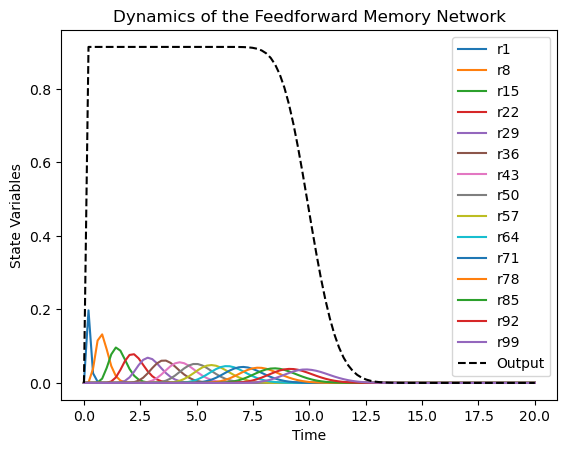

In [8]:
n = 100
tau = 0.1
W = np.ones(n)
x0 = np.zeros(n)
t_span = (0, 2*n*tau)
t_eval = np.linspace(*t_span, 100)
solution = solve_ivp(
    fun=lambda t, x: dynamics(t, x, W, tau, pulse),
    t_span=t_span,
    y0=x0,
    t_eval=t_eval
)

import matplotlib.pyplot as plt
plt.plot(solution.t, solution.y.T[:,::7])
plt.plot(solution.t, solution.y.T[:,-1], 'k--', label='Output')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.title('Dynamics of the Feedforward Memory Network')
plt.legend([f'r{i}' for i in range(1,n,7)] + ['Output'])
plt.show()

$$ r_n = \frac{1}{n!} \hat{t}^n e^{-\hat t} $$

We want to find optimal weights?